# EEG_07f — Preprocessing: Graph & Hypergraph Tensors

Sostituisce EEG_07e. Per ogni trial CSV di Paolo produce:
- `graphs/`             → grafo non-pruned (edge_index + edge_attr)
- `graphs_pruned/`      → grafo con consensus pruning
- `hypergraphs/`        → ipergrafo non-pruned (incidence matrix H)
- `hypergraphs_pruned/` → ipergrafo con consensus pruning

**Sorgente dati**: `data/raw_csv/training_set/PXXX_SYYY/word_img.csv`  
**Shape CSV**: (61 canali × 384 campioni), no header, float32  
**Paradigma**: 1 file .pt per trial — mai file monolitici


In [5]:
import json
import logging
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.signal import hilbert
from tqdm.auto import tqdm


In [6]:
# ============================================================
# CONFIG — modifica qui, poi Kernel → Restart & Run All
# ============================================================

# Metriche per cui costruire i grafi — una directory di output per metrica.
# Ablation: metti tutte e 5 per confronto completo.
METRICS = ["pcc", "abs_pcc", "im_pcc", "wpli", "plv"]

# Metriche usate per il consensus pruning (indipendente da METRICS)
CONSENSUS_METRICS = ["wpli", "plv", "abs_pcc", "im_pcc"]

# Soglia consensus: None = maggioranza (ceil(n/2)); int = fisso
CONSENSUS_K = None

# Top-X% per metric: arco significativo se |valore| >= percentile X
EDGE_THRESHOLD_PCT = 80     # top 20% archi per metrica

# k vicini per iperedge (costruzione matrice di incidenza H)
K_HYPEREDGE = 6

# Salta trial già processati (utile per resume dopo crash)
OVERWRITE = False


In [7]:
# ============================================================
# SETUP — path, logging, mapping parola → label_idx
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("eeg07f")

# Root di progetto
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve(),
)

CSV_ROOT = project_root / "data" / "raw_csv" / "training_set"
DATA_OUT = project_root / "data"   # graphs_{metric}/ e graphs_pruned_{metric}/ qui sotto

assert CSV_ROOT.exists(), f"CSV_ROOT non trovato: {CSV_ROOT}"
log.info(f"project_root : {project_root}")
log.info(f"CSV_ROOT     : {CSV_ROOT}")

# word → label_idx
_label2idx_path = project_root / "configs" / "label_schemes" / "label2idx.json"
word2label: dict = json.loads(_label2idx_path.read_text())
log.info(f"Vocabolario  : {len(word2label)} parole")

# Verifica metriche configurate
_VALID_METRICS = {"pcc", "abs_pcc", "im_pcc", "wpli", "plv"}
assert all(m in _VALID_METRICS for m in METRICS), f"Metrica non valida in METRICS"
assert all(m in _VALID_METRICS for m in CONSENSUS_METRICS), f"Metrica non valida in CONSENSUS_METRICS"

_eff_k = CONSENSUS_K if CONSENSUS_K is not None else __import__("math").ceil(len(CONSENSUS_METRICS) / 2)
log.info(f"METRICS      : {METRICS}")
log.info(f"Consensus    : {CONSENSUS_METRICS}  k={_eff_k}/{len(CONSENSUS_METRICS)}")
log.info(f"Threshold    : percentile {EDGE_THRESHOLD_PCT} → top {100-EDGE_THRESHOLD_PCT:.0f}%")


21:23:59  INFO      project_root : /home/daniele_u/miralis-hypergraph-imagined-speech
21:23:59  INFO      CSV_ROOT     : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
21:23:59  INFO      Vocabolario  : 110 parole
21:23:59  INFO      METRICS      : ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']
21:23:59  INFO      Consensus    : ['wpli', 'plv', 'abs_pcc', 'im_pcc']  k=2/4
21:23:59  INFO      Threshold    : percentile 80 → top 20%


In [8]:
# ============================================================
# METRICHE DI CONNETTIVITÀ
# Ogni funzione riceve x: (N_ch, N_samples) float32
# Restituisce matrice (N, N) float32, diagonale = 0
# ============================================================

def _pcc(x: np.ndarray) -> np.ndarray:
    """Pearson Correlation Coefficient."""
    mat = np.corrcoef(x).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _abs_pcc(x: np.ndarray) -> np.ndarray:
    """Valore assoluto del PCC."""
    return np.abs(_pcc(x))


def _im_pcc(x: np.ndarray) -> np.ndarray:
    """
    Parte immaginaria della coerenza complessa (imaginary coherence).
    Basata sull'analytic signal via Hilbert — insensibile alla conduzione
    di volume (componenti a zero-lag si cancellano).
    Ref: Nolte et al. 2004 (Clin Neurophysiol).
    """
    z = hilbert(x, axis=1)              # segnale analitico (N, T)
    N, T = z.shape
    # Matrice di cross-correlazione normalizzata
    cross = (z @ z.conj().T) / T        # (N, N), unnormalised
    norms = np.sqrt(np.mean(np.abs(z) ** 2, axis=1))   # (N,)
    norm_mat = np.outer(norms, norms) + 1e-12
    coherency = cross / norm_mat        # coerenza complessa (N, N)
    mat = np.imag(coherency).astype(np.float32)
    np.fill_diagonal(mat, 0.0)
    return mat


def _wpli(x: np.ndarray) -> np.ndarray:
    """
    Weighted Phase Lag Index.
    wPLI[i,j] = |E[Im(Sxy)]| / E[|Im(Sxy)|]
    Ref: Vinck et al. 2011 (NeuroImage).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    N = x.shape[0]
    wpli = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross_im = np.imag(z[i] * np.conj(z))  # (N, T)
        num = np.abs(np.mean(cross_im, axis=1))
        den = np.mean(np.abs(cross_im), axis=1) + 1e-10
        wpli[i] = (num / den).astype(np.float32)
    np.fill_diagonal(wpli, 0.0)
    return wpli


def _plv(x: np.ndarray) -> np.ndarray:
    """
    Phase Locking Value.
    PLV[i,j] = |mean_t( exp(i*(phi_i - phi_j)) )|
    Ref: Lachaux et al. 1999 (Human Brain Mapping).
    """
    z = hilbert(x, axis=1)              # (N, T) analytic signal
    phases = z / (np.abs(z) + 1e-10)   # (N, T) unit complex
    N = x.shape[0]
    plv = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        cross = phases[i] * np.conj(phases)     # (N, T)
        plv[i] = np.abs(np.mean(cross, axis=1)).astype(np.float32)
    np.fill_diagonal(plv, 0.0)
    return plv


_METRIC_FNS = {
    "pcc":     _pcc,
    "abs_pcc": _abs_pcc,
    "im_pcc":  _im_pcc,
    "wpli":    _wpli,
    "plv":     _plv,
}


def compute_metric(x: np.ndarray, metric: str) -> np.ndarray:
    """Calcola metrica di connettività per un singolo trial."""
    return _METRIC_FNS[metric](x)


print("Metriche OK:", list(_METRIC_FNS.keys()))


Metriche OK: ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']


In [9]:
# ============================================================
# CONSENSUS PRUNING — majority vote su metriche multiple
# ============================================================

def _significance_mask(mat: np.ndarray, threshold_pct: float) -> np.ndarray:
    """
    Maschera binaria: 1 se |valore| >= percentile threshold_pct dei valori
    off-diagonali. Funziona su metriche sia positive che signed.

    Args:
        mat:           (N, N) matrice di connettività
        threshold_pct: percentile (es. 80 → soglia al p80, top 20% archi)

    Returns: (N, N) bool array, diagonale sempre False
    """
    N = mat.shape[0]
    vals = np.abs(mat)
    np.fill_diagonal(vals, 0.0)
    off_diag = vals[~np.eye(N, dtype=bool)]
    thr = np.percentile(off_diag, threshold_pct)
    mask = (vals >= thr)
    np.fill_diagonal(mask, False)
    return mask


def compute_consensus_mask(
    x: np.ndarray,
    consensus_metrics: list[str],
    threshold_pct: float,
    k: int | None,
) -> np.ndarray:
    """
    Consensus mask: majority vote su più metriche.

    Per ogni metrica in consensus_metrics:
      1. Calcola matrice di connettività
      2. Applica soglia al percentile threshold_pct → maschera binaria

    Somma le maschere → consensus_score[i,j] = n. metriche che concordano.
    Tieni solo gli archi con consensus_score >= k.

    Args:
        x:                 (N, T) trial EEG normalizzato
        consensus_metrics: lista di nomi metrica
        threshold_pct:     soglia per singola metrica (percentile)
        k:                 soglia minima consensus (None = ceil(n/2))

    Returns: (N, N) bool array — True = arco sopravvive al pruning
    """
    n_metrics = len(consensus_metrics)
    eff_k = math.ceil(n_metrics / 2) if k is None else k
    N = x.shape[0]
    vote_sum = np.zeros((N, N), dtype=np.int8)

    for metric in consensus_metrics:
        mat  = compute_metric(x, metric)
        mask = _significance_mask(mat, threshold_pct)
        vote_sum += mask.astype(np.int8)

    consensus = vote_sum >= eff_k
    np.fill_diagonal(consensus, False)
    return consensus


print("Consensus masking OK")


Consensus masking OK


In [10]:
# ============================================================
# COSTRUTTORI GRAFO E IPERGRAFO
# ============================================================

def _adj_to_sparse(adj: np.ndarray):
    """
    Converte matrice di adiacenza (N, N) in edge_index [2, E] + edge_attr [E].
    """
    rows, cols = np.where(adj != 0.0)
    edge_index = torch.tensor(np.stack([rows, cols], axis=0), dtype=torch.long)
    edge_attr  = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_attr


def build_graph_dict(
    x_norm: np.ndarray,
    metric: str,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario PyG-compatibile per un singolo trial.

    Args:
        x_norm:         (N, T) EEG normalizzato per-canale
        metric:         nome metrica per pesi archi
        label:          class label intero
        meta:           dizionario metadati trial
        consensus_mask: (N, N) bool — se None, nessun pruning

    Returns dict con chiavi: edge_index, edge_attr, x, adj, y, meta
    """
    adj_full = compute_metric(x_norm, metric)           # (N, N) float

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    edge_index, edge_attr = _adj_to_sparse(adj_eff)

    return {
        "edge_index": edge_index,                                   # [2, E]
        "edge_attr":  edge_attr,                                    # [E]
        "x":          torch.tensor(x_norm, dtype=torch.float32),   # [N, T]
        "adj":        torch.tensor(adj_eff, dtype=torch.float32),  # [N, N]
        "y":          torch.tensor(label,  dtype=torch.long),
        "meta":       meta,
    }


def _build_incidence_matrix(adj: np.ndarray, k: int) -> np.ndarray:
    """
    Costruisce matrice di incidenza H di shape (N_nodes, N_hyperedges).

    Ogni nodo i genera un iperedge che include se stesso + i top-k vicini
    secondo la matrice adj. Se adj è già pruned, i vicini disconnessi
    vengono esclusi naturalmente.

    H[n, e] = 1 se il nodo n appartiene all'iperedge e, altrimenti 0.
    """
    N = adj.shape[0]
    H = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        row = adj[i].copy()
        row[i] = 0.0                                    # escludi self
        sorted_neighbors = np.argsort(row)[::-1]        # decrescente per valore
        connected = sorted_neighbors[row[sorted_neighbors] > 0]   # solo archi esistenti
        top_k_neigh = connected[:k]                     # al più k vicini
        members = np.concatenate([[i], top_k_neigh])
        H[members, i] = 1.0

    return H


def build_hypergraph_dict(
    x_norm: np.ndarray,
    metric: str,
    k_hyperedge: int,
    label: int,
    meta: dict,
    consensus_mask: np.ndarray | None = None,
) -> dict:
    """
    Costruisce dizionario ipergrafo per un singolo trial.
    Usa la matrice di incidenza H invece di edge_index/edge_attr.

    Un iperedge è definito da un nodo centrale + i suoi top-k vicini.
    Se consensus_mask è fornita, solo gli archi che superano il pruning
    contribuiscono alla membership dell'iperedge.
    """
    adj_full = compute_metric(x_norm, metric)

    if consensus_mask is not None:
        adj_eff = adj_full * consensus_mask.astype(np.float32)
    else:
        adj_eff = adj_full

    H = _build_incidence_matrix(adj_eff, k=k_hyperedge)

    return {
        "H":    torch.tensor(H,        dtype=torch.float32),   # [N, N_hyperedges]
        "x":    torch.tensor(x_norm,   dtype=torch.float32),   # [N, T]
        "adj":  torch.tensor(adj_eff,  dtype=torch.float32),   # [N, N]
        "y":    torch.tensor(label,    dtype=torch.long),
        "meta": meta,
    }


print("Graph & hypergraph builders OK")


Graph & hypergraph builders OK


In [11]:
# ============================================================
# I/O — caricamento CSV, normalizzazione, salvataggio .pt
# ============================================================

def load_trial(csv_path: Path) -> np.ndarray:
    """
    Carica un trial CSV di Paolo.
    Shape attesa: (61, 384) — righe=canali, colonne=campioni temporali.
    Nessun header, valori float separati da virgola.
    """
    x = pd.read_csv(csv_path, header=None).values.astype(np.float32)
    if x.ndim != 2:
        raise ValueError(f"Shape inattesa {x.shape} in {csv_path}")
    return x  # (N_ch, N_samples)


def normalize_trial(x: np.ndarray) -> np.ndarray:
    """
    Z-score per-canale: (x - mean) / std su asse temporale.
    Clip std a 1e-6 per evitare divisione per zero.
    """
    mean = x.mean(axis=1, keepdims=True)
    std  = x.std(axis=1,  keepdims=True).clip(1e-6)
    return (x - mean) / std


def save_pt(data: dict, path: Path) -> None:
    """Salva dizionario come .pt, crea le cartelle necessarie."""
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(data, path)


print("I/O utilities OK")


I/O utilities OK


In [12]:
# ============================================================
# MAIN LOOP — per sessione → per trial → per metrica
# Consensus mask calcolata UNA VOLTA per trial (non dipende da METRICS)
# ============================================================

def _out_path(base: Path, metric: str, pruned: bool,
              subj_id: int, sess_id: int, trial_idx: int) -> Path:
    """graphs_{metric}/ o graphs_pruned_{metric}/ / P{xxx}_S{yyy}/trial_{zzz}.pt"""
    kind   = "graphs_pruned" if pruned else "graphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def _out_path_hg(base: Path, metric: str, pruned: bool,
                 subj_id: int, sess_id: int, trial_idx: int) -> Path:
    kind   = "hypergraphs_pruned" if pruned else "hypergraphs"
    folder = f"P{subj_id:03d}_S{sess_id:03d}"
    return DATA_OUT / f"{kind}_{metric}" / folder / f"trial_{trial_idx:03d}.pt"


def process_session(session_dir: Path, subj_id: int, sess_id: int) -> tuple[int, int]:
    """Processa tutti i trial di una sessione per tutte le METRICS."""
    csv_files = sorted(session_dir.glob("*_img.csv"))
    n_proc = n_skip = 0

    for trial_idx, csv_path in enumerate(
        tqdm(csv_files, desc=f"  P{subj_id:03d}_S{sess_id:03d}", leave=False)
    ):
        word = csv_path.stem.replace("_img", "")
        if word not in word2label:
            n_skip += 1
            continue

        label = word2label[word]

        # Controlla se TUTTI i file di output esistono già
        all_exist = all(
            _out_path(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists() and
            _out_path_hg(DATA_OUT, m, pruned, subj_id, sess_id, trial_idx).exists()
            for m in METRICS for pruned in [False, True]
        )
        if not OVERWRITE and all_exist:
            n_proc += 1
            continue

        # Carica e normalizza (una sola volta per trial)
        x_norm = normalize_trial(load_trial(csv_path))  # (61, 384)

        # Consensus mask — calcolata ONCE per trial, usata da tutte le metriche
        cons_mask = compute_consensus_mask(
            x_norm, CONSENSUS_METRICS, EDGE_THRESHOLD_PCT, CONSENSUS_K
        )

        _meta_base = {
            "subject_id":        subj_id,
            "session_id":        sess_id,
            "trial_idx":         trial_idx,
            "word":              word,
            "consensus_metrics": CONSENSUS_METRICS,
            "consensus_k":       _eff_k,
        }

        # Loop su tutte le metriche richieste
        for metric in METRICS:
            _meta = {**_meta_base, "metric": metric}

            # Grafo non-pruned
            p_g = _out_path(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_g.exists():
                save_pt(build_graph_dict(
                    x_norm, metric, label, {**_meta, "pruned": False}
                ), p_g)

            # Grafo pruned
            p_gp = _out_path(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_gp.exists():
                save_pt(build_graph_dict(
                    x_norm, metric, label, {**_meta, "pruned": True},
                    consensus_mask=cons_mask,
                ), p_gp)

            # Ipergrafo non-pruned
            p_h = _out_path_hg(DATA_OUT, metric, False, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_h.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": False}
                ), p_h)

            # Ipergrafo pruned
            p_hp = _out_path_hg(DATA_OUT, metric, True, subj_id, sess_id, trial_idx)
            if OVERWRITE or not p_hp.exists():
                save_pt(build_hypergraph_dict(
                    x_norm, metric, K_HYPEREDGE, label, {**_meta, "pruned": True},
                    consensus_mask=cons_mask,
                ), p_hp)

        del x_norm, cons_mask
        n_proc += 1

    return n_proc, n_skip


# ── Avvia ──────────────────────────────────────────────────
_pat = __import__("re").compile(r"^P(\d+)_S(\d+)$")
session_dirs = sorted(
    [d for d in CSV_ROOT.iterdir() if d.is_dir() and _pat.match(d.name)]
)
log.info(f"Directory sessioni: {len(session_dirs)}")
log.info(f"Output per metrica: {[f'graphs_{m}' for m in METRICS]}")

total_proc = total_skip = 0

for session_dir in tqdm(session_dirs, desc="Sessioni"):
    m = _pat.match(session_dir.name)
    subj_id, sess_id = int(m.group(1)), int(m.group(2))
    log.info(f"Inizio: {session_dir.name}")
    n_proc, n_skip = process_session(session_dir, subj_id, sess_id)
    total_proc += n_proc
    total_skip += n_skip
    log.info(f"Fine  : {session_dir.name} — {n_proc} proc, {n_skip} skip")

log.info(f"Done. {total_proc} processati, {total_skip} saltati.")


21:23:59  INFO      Directory sessioni: 357
21:23:59  INFO      Output per metrica: ['graphs_pcc', 'graphs_abs_pcc', 'graphs_im_pcc', 'graphs_wpli', 'graphs_plv']


Sessioni:   0%|          | 0/357 [00:00<?, ?it/s]

21:23:59  INFO      Inizio: P000_S001


  P000_S001:   0%|          | 0/110 [00:00<?, ?it/s]

21:23:59  INFO      Fine  : P000_S001 — 110 proc, 0 skip
21:23:59  INFO      Inizio: P000_S002


...

21:24:07  INFO      Fine  : P072_S004 — 110 proc, 0 skip
21:24:07  INFO      Inizio: P072_S005


  P072_S005:   0%|          | 0/110 [00:00<?, ?it/s]

21:24:07  INFO      Fine  : P072_S005 — 110 proc, 0 skip
21:24:07  INFO      Inizio: P073_S001


  P073_S001:   0%|          | 0/110 [00:00<?, ?it/s]

21:24:07  INFO      Fine  : P073_S001 — 110 proc, 0 skip
21:24:07  INFO      Done. 38883 processati, 0 saltati.


In [13]:
# ============================================================
# VERIFICA — conteggio e struttura per ogni metrica
# ============================================================
import random

for metric in METRICS:
    for kind, keys in [
        (f"graphs_{metric}",          ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"graphs_pruned_{metric}",   ["edge_index","edge_attr","x","adj","y","meta"]),
        (f"hypergraphs_{metric}",      ["H","x","adj","y","meta"]),
        (f"hypergraphs_pruned_{metric}",["H","x","adj","y","meta"]),
    ]:
        base = DATA_OUT / kind
        pts  = list(base.rglob("*.pt")) if base.exists() else []
        if not pts:
            print(f"  [{kind:<35}]  0 file")
            continue
        sample = torch.load(random.choice(pts), weights_only=False)
        missing = [k for k in keys if k not in sample]
        n_e = sample["edge_index"].shape[1] if "edge_index" in sample else "-"
        h_s = tuple(sample["H"].shape) if "H" in sample else "-"
        print(
            f"  [{kind:<35}]  {len(pts):>6} file  "
            f"x={tuple(sample['x'].shape)}  edges={n_e}  H={h_s}  "
            f"{'OK' if not missing else 'MISSING:' + str(missing)}"
        )


  [graphs_pcc                         ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_pcc                  ]   38883 file  x=(61, 384)  edges=1104  H=-  OK
  [hypergraphs_pcc                    ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_pcc             ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [graphs_abs_pcc                     ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_abs_pcc              ]   38883 file  x=(61, 384)  edges=1192  H=-  OK
  [hypergraphs_abs_pcc                ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_abs_pcc         ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [graphs_im_pcc                      ]   38883 file  x=(61, 384)  edges=3660  H=-  OK
  [graphs_pruned_im_pcc               ]   38883 file  x=(61, 384)  edges=1016  H=-  OK
  [hypergraphs_im_pcc                 ]   38883 file  x=(61, 384)  edges=-  H=(61, 61)  OK
  [hypergraphs_pruned_i

## Visualizzazione — Grafi & Ipergrafi per Soggetto/Parola

P000_S001  |  guerra  |  trial_idx=48
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07f_viz_P000_S001_guerra.png


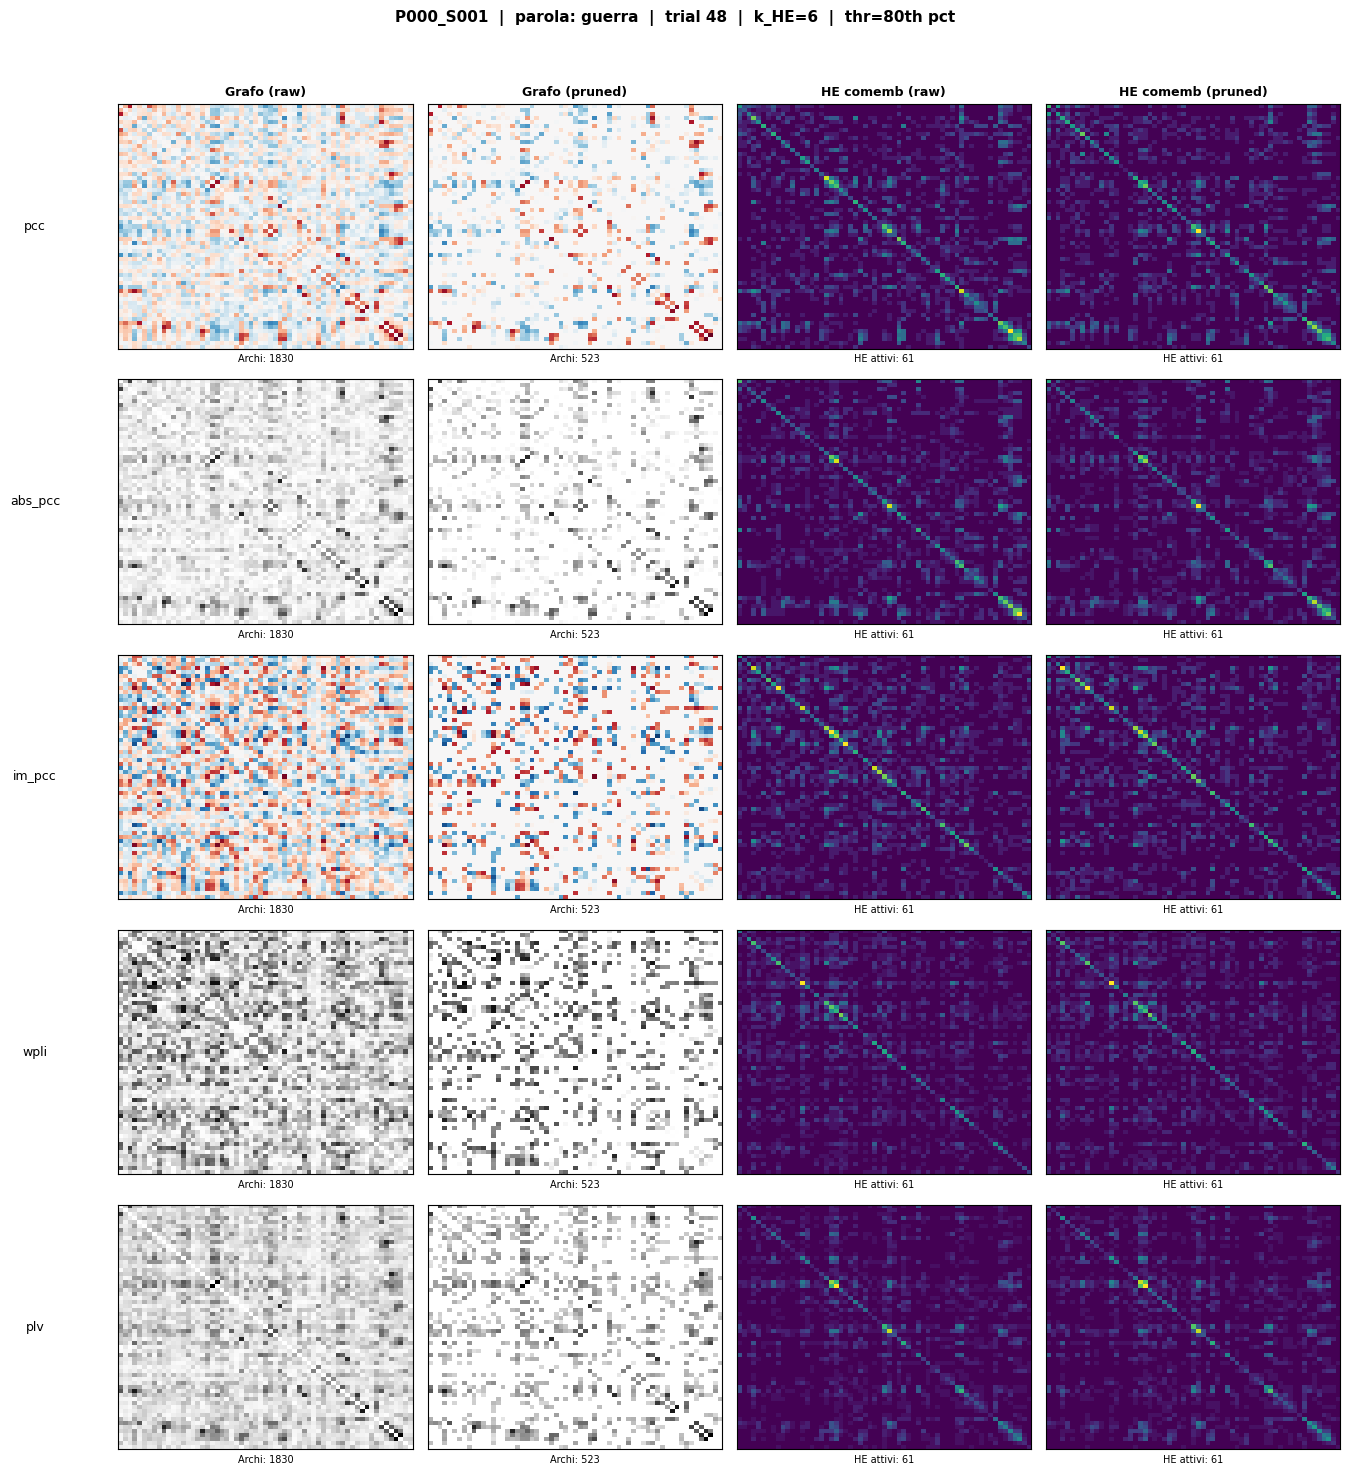

In [14]:
# ============================================================
# VISUALIZZAZIONE — grafi e ipergrafi (pruned / raw) per trial
# Modifica solo i 3 parametri qui sotto, poi esegui la cella.
# Richiede che il main loop (cella 8) sia già stato eseguito.
# ============================================================

import matplotlib.pyplot as plt

VIZ_SUBJ_ID = 0           # es. 0 → P000
VIZ_SESS_ID = 1           # es. 1 → S001
VIZ_WORD    = "guerra" # parola senza _img.csv

# ---- risolvi trial_idx dalla posizione nel glob ----
_sess_dir  = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_csv_files = sorted(_sess_dir.glob("*_img.csv"))
_trial_idx = next(
    (i for i, p in enumerate(_csv_files) if p.stem == f"{VIZ_WORD}_img"),
    None,
)
if _trial_idx is None:
    raise FileNotFoundError(f"'{VIZ_WORD}' non trovata in {_sess_dir}")
print(f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  {VIZ_WORD}  |  trial_idx={_trial_idx}")

# ---- carica tutti i .pt per questo trial ----
_KINDS   = ["graphs", "graphs_pruned", "hypergraphs", "hypergraphs_pruned"]
_loaded  = {}
for _metric in METRICS:
    for _kind in _KINDS:
        _pt = _out_path(DATA_OUT, _metric, "pruned" in _kind,
                        VIZ_SUBJ_ID, VIZ_SESS_ID, _trial_idx) \
              if "hypergraph" not in _kind else \
              _out_path_hg(DATA_OUT, _metric, "pruned" in _kind,
                           VIZ_SUBJ_ID, VIZ_SESS_ID, _trial_idx)
        _loaded[(_kind, _metric)] = (
            torch.load(_pt, weights_only=False) if _pt.exists() else None
        )

# ---- figura: righe=metriche, colonne=4 varianti ----
_COL_LABELS = ["Grafo (raw)", "Grafo (pruned)", "HE comemb (raw)", "HE comemb (pruned)"]
_SIGNED     = {"pcc", "im_pcc"}   # metriche con valori negativi → RdBu_r

n_r, n_c = len(METRICS), 4
fig, axes = plt.subplots(n_r, n_c, figsize=(n_c * 3.4, n_r * 3.0))
if n_r == 1:
    axes = axes[np.newaxis, :]

for ri, metric in enumerate(METRICS):
    axes[ri, 0].set_ylabel(metric, fontsize=9, rotation=0,
                            labelpad=60, va="center")

    for ci, kind in enumerate(_KINDS):
        ax   = axes[ri, ci]
        data = _loaded.get((kind, metric))

        if data is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            continue

        if "hypergraph" in kind:
            # co-membership: H @ H.T  →  quante HE condividono i e j
            H_np = data["H"].numpy()            # (N, N_he)
            mat  = H_np @ H_np.T                # (N, N)
            vmax = mat.max() if mat.max() > 0 else 1.0
            ax.imshow(mat, cmap="viridis", vmin=0, vmax=vmax,
                      aspect="auto", interpolation="nearest")
            n_he = int((H_np.sum(axis=0) > 0).sum())
            ax.set_xlabel(f"HE attivi: {n_he}", fontsize=7)
        else:
            adj_np = data["adj"].numpy()        # (N, N)
            vmax   = np.abs(adj_np).max() or 1.0
            if metric in _SIGNED:
                ax.imshow(adj_np, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                          aspect="auto", interpolation="nearest")
            else:
                ax.imshow(adj_np, cmap="Greys", vmin=0, vmax=vmax,
                          aspect="auto", interpolation="nearest")
            n_edges = int(data["edge_index"].shape[1] // 2)
            ax.set_xlabel(f"Archi: {n_edges}", fontsize=7)

        ax.set_xticks([]); ax.set_yticks([])

for ci, lbl in enumerate(_COL_LABELS):
    axes[0, ci].set_title(lbl, fontsize=9, fontweight="bold")

fig.suptitle(
    f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  parola: {VIZ_WORD}"
    f"  |  trial {_trial_idx}  |  k_HE={K_HYPEREDGE}  |  thr={EDGE_THRESHOLD_PCT}th pct",
    fontsize=11, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.96])

_out_viz = project_root / "figures" / (
    f"eeg07f_viz_P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}_{VIZ_WORD}.png"
)
fig.savefig(_out_viz, dpi=150, bbox_inches="tight")
print(f"Salvato: {_out_viz}")
plt.show()


Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/topomap_P000_guerra.png


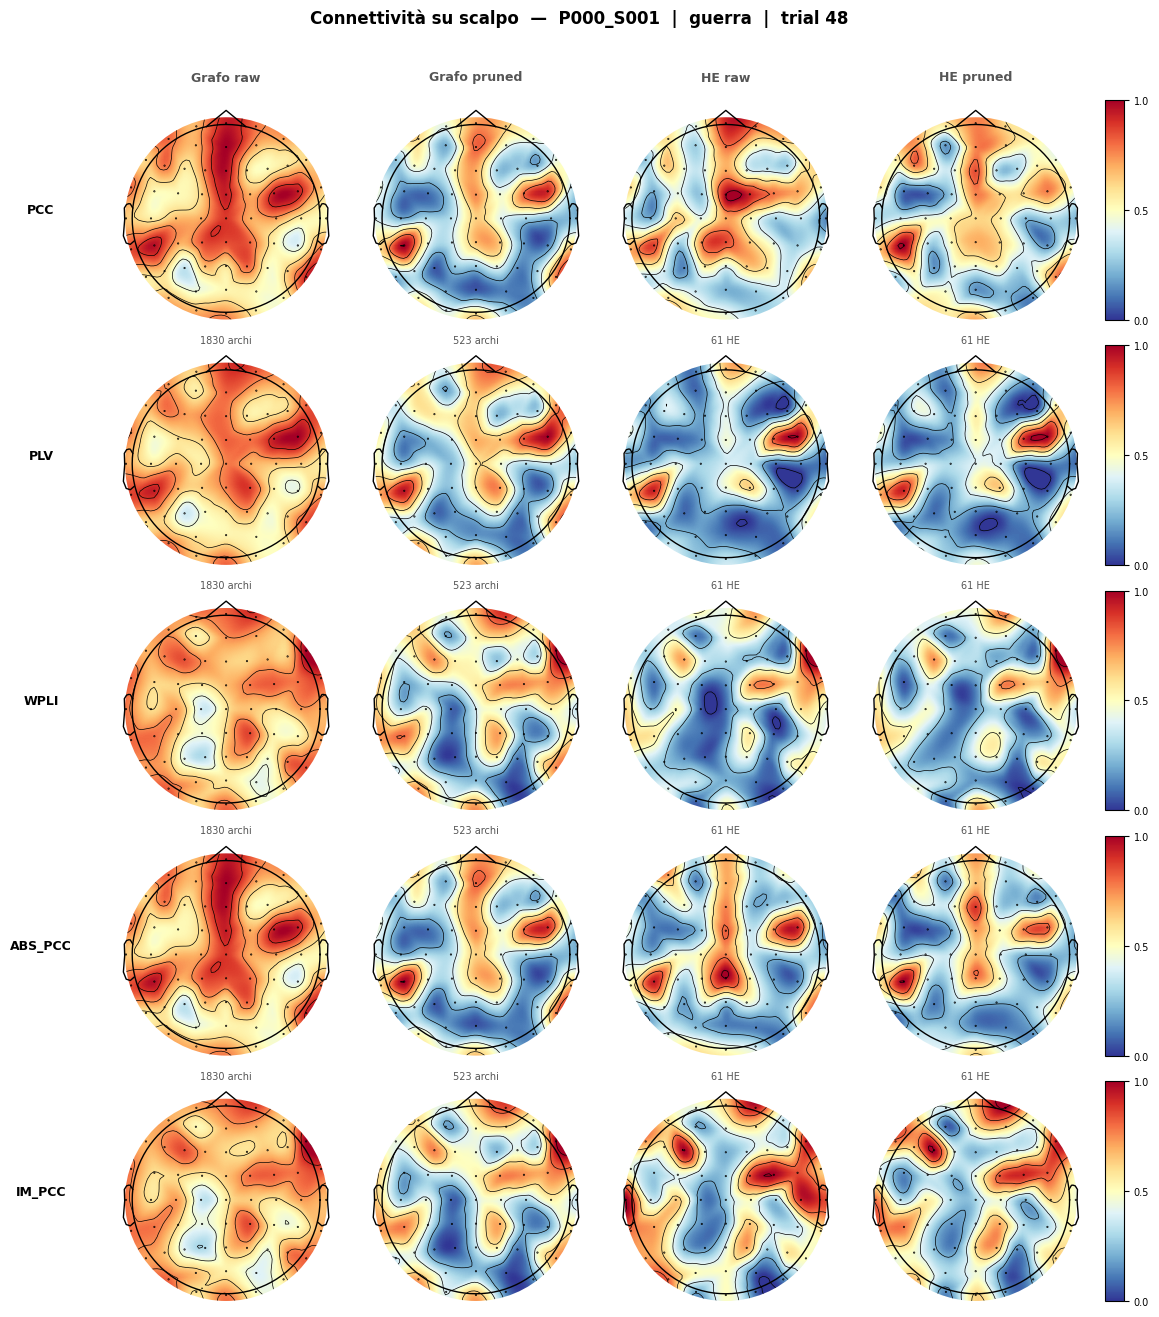

In [32]:
# ============================================================
# TOPOMAP CONNETTIVITÀ SU SCALPO
# ============================================================
import mne, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path

VIZ_SUBJ_ID = 0
VIZ_SESS_ID = 1
VIZ_WORD    = "guerra"
N_CH        = 61

# ---- montage ----
_RENAME = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}
_BAD    = {"A1", "A2"}
ELOC_FILE = project_root / "src" / "io" / "ebneuro.locs"

_raw_montage = mne.channels.read_custom_montage(str(ELOC_FILE), coord_frame="head")
_ch_pos  = {_RENAME.get(ch, ch): pos
            for ch, pos in _raw_montage.get_positions()["ch_pos"].items()
            if ch not in _BAD}
_montage = mne.channels.make_dig_montage(ch_pos=_ch_pos, coord_frame="head")
ch_names = [_RENAME.get(ch, ch) for ch in _raw_montage.ch_names if ch not in _BAD][:N_CH]

info = mne.create_info(ch_names=ch_names, sfreq=256, ch_types="eeg")
info.set_montage(_montage, on_missing="warn")

# ---- scalare per nodo ----
def _node_scalar(data: dict) -> np.ndarray:
    """
    Grafo     → grado pesato: sum(|adj|, axis=1)
    Ipergrafo → membership:   sum(H,     axis=1)
    """
    if "H" in data:
        v = data["H"].numpy().sum(axis=1)           # (N,)
    elif "adj" in data:
        v = np.abs(data["adj"].numpy()).sum(axis=1)  # (N,)
    else:
        return np.zeros(N_CH)
    mx = v.max()
    return (v / (mx + 1e-8)) if mx > 0 else v

# ---- risolvi trial_idx ----
_sess_dir  = CSV_ROOT / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
_trial_idx = next(
    (i for i, p in enumerate(sorted(_sess_dir.glob("*_img.csv")))
     if p.stem == f"{VIZ_WORD}_img"), None
)
if _trial_idx is None:
    raise FileNotFoundError(f"'{VIZ_WORD}' non trovata in {_sess_dir}")

# ---- carica .pt ----
_KINDS = ["graphs", "graphs_pruned", "hypergraphs", "hypergraphs_pruned"]
_loaded = {}
for m in METRICS:
    for k in _KINDS:
        pt = (DATA_OUT / f"{k}_{m}"
              / f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}"
              / f"trial_{_trial_idx:03d}.pt")
        _loaded[(k, m)] = torch.load(pt, weights_only=False) if pt.exists() else None

# ---- figura ----
_COL_TITLES = ["Grafo raw", "Grafo pruned", "HE raw", "HE pruned"]
_CMAP       = "RdYlBu_r"
n_r, n_c    = len(METRICS), len(_KINDS)

fig, axes = plt.subplots(
    n_r, n_c + 1,                          # +1 colonna destra per colorbar
    figsize=(n_c * 2.8 + 0.5, n_r * 2.6),
    gridspec_kw={"width_ratios": [1] * n_c + [0.08]},
)

norm = Normalize(vmin=0, vmax=1)
sm   = ScalarMappable(cmap=_CMAP, norm=norm)
sm.set_array([])

for ri, metric in enumerate(METRICS):
    axes[ri, 0].set_ylabel(
        metric.upper(), fontsize=9, fontweight="bold",
        rotation=0, labelpad=52, va="center",
    )
    for ci, kind in enumerate(_KINDS):
        ax   = axes[ri, ci]
        data = _loaded.get((kind, metric))

        if data is None:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#aaa")
            ax.axis("off")
            continue

        vals = _node_scalar(data)
        mne.viz.plot_topomap(
            vals, info, axes=ax,
            cmap=_CMAP, vlim=(0, 1),
            contours=5, show=False,
            extrapolate="head",
        )

        # annotazione n. archi / HE attivi
        if "H" in data:
            tag = f"{int((data['H'].sum(axis=0) > 0).sum())} HE"
        else:
            tag = f"{int(data['edge_index'].shape[1] // 2)} archi"
        ax.set_title(tag, fontsize=7, color="#555", pad=2)

    # colorbar per riga (nell'ultima colonna)
    plt.colorbar(sm, cax=axes[ri, -1]).set_ticks([0, 0.5, 1])
    axes[ri, -1].tick_params(labelsize=7)

# intestazioni colonne
for ci, lbl in enumerate(_COL_TITLES):
    axes[0, ci].set_title(lbl, fontsize=9, fontweight="bold", pad=14)

fig.suptitle(
    f"Connettività su scalpo  —  "
    f"P{VIZ_SUBJ_ID:03d}_S{VIZ_SESS_ID:03d}  |  {VIZ_WORD}  |  trial {_trial_idx}",
    fontsize=12, fontweight="bold", y=1.01,
)
fig.tight_layout()

_out = project_root / "figures" / f"topomap_P{VIZ_SUBJ_ID:03d}_{VIZ_WORD}.png"
fig.savefig(_out, dpi=160, bbox_inches="tight")
print(f"Salvato: {_out}")
plt.show()

In [33]:
def _node_scalar(data_obj) -> np.ndarray:
    if data_obj is None:
        return np.zeros(N_CH)

    d = data_obj if isinstance(data_obj, dict) else data_obj.__dict__

    if "H" in d:
        # ipergrafo: H shape (N, N_he) → quante HE include ogni nodo
        H_np = d["H"].numpy() if isinstance(d["H"], torch.Tensor) else np.array(d["H"])
        v = H_np.sum(axis=1)
    elif "adj" in d:
        # grafo: grado pesato
        adj = d["adj"]
        adj_np = adj.numpy() if isinstance(adj, torch.Tensor) else np.array(adj)
        v = np.abs(adj_np).sum(axis=1)
    elif "edge_index" in d:
        idx = d["edge_index"][0]
        idx_np = idx.cpu().numpy() if isinstance(idx, torch.Tensor) else np.array(idx)
        v = np.bincount(idx_np, minlength=N_CH).astype(float)[:N_CH]
    else:
        return np.zeros(N_CH)

    v = np.asarray(v, dtype=float)
    mx = v.max()
    return v / (mx + 1e-8) if mx > 0 else v


# debug corretto: per HE mostra hyperedge attivi, non "connessioni"
for metric in METRICS:
    for kind in _KINDS:
        data = _loaded.get((kind, metric))
        if data is None: continue
        d = data if isinstance(data, dict) else data.__dict__
        if "H" in d:
            n_e = int((d["H"].sum(axis=0) > 0).sum())
            print(f"DEBUG: {metric} {kind} → {n_e} HE attivi")
        else:
            ei = d.get("edge_index", torch.zeros(2, 0))
            print(f"DEBUG: {metric} {kind} → {ei.shape[-1]} archi")

DEBUG: pcc graphs → 3660 archi
DEBUG: pcc graphs_pruned → 1046 archi
DEBUG: pcc hypergraphs → 61 HE attivi
DEBUG: pcc hypergraphs_pruned → 61 HE attivi
DEBUG: plv graphs → 3660 archi
DEBUG: plv graphs_pruned → 1046 archi
DEBUG: plv hypergraphs → 61 HE attivi
DEBUG: plv hypergraphs_pruned → 61 HE attivi
DEBUG: wpli graphs → 3660 archi
DEBUG: wpli graphs_pruned → 1046 archi
DEBUG: wpli hypergraphs → 61 HE attivi
DEBUG: wpli hypergraphs_pruned → 61 HE attivi
DEBUG: abs_pcc graphs → 3660 archi
DEBUG: abs_pcc graphs_pruned → 1046 archi
DEBUG: abs_pcc hypergraphs → 61 HE attivi
DEBUG: abs_pcc hypergraphs_pruned → 61 HE attivi
DEBUG: im_pcc graphs → 3660 archi
DEBUG: im_pcc graphs_pruned → 1046 archi
DEBUG: im_pcc hypergraphs → 61 HE attivi
DEBUG: im_pcc hypergraphs_pruned → 61 HE attivi
